✓ Loaded MIROC6: 5 regions
✓ Loaded NorESM2-LM: 5 regions
✓ Loaded NorESM2-MM: 5 regions
✓ Loaded CMCC-CM2-SR5: 5 regions
✓ Loaded CMCC-ESM2: 5 regions

Ensemble statistics:
  region  delta_dep  pct_change_M3  Delta_mm_day
0    NMZ   0.163239      27.799196      0.063380
1    NSZ   0.020285      54.351181     -0.093511
2    SMZ   0.008622     -18.972991      0.042750
3    SSZ   0.053776      24.086208     -0.242565
4   TROP  -0.121507      26.191272     -0.039671


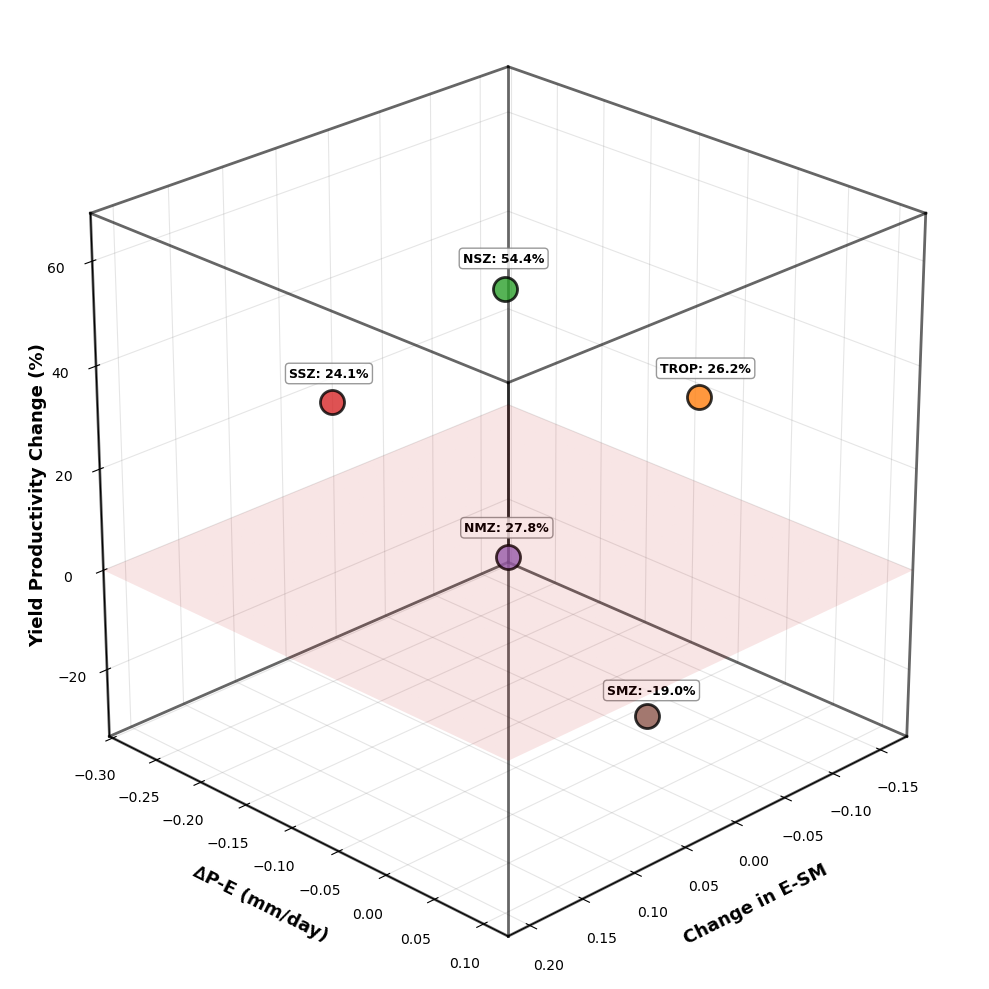


Figures saved:
- 'coupling_vs_yield_3D_cube_view2.png'

Ensemble data saved to 'ensemble_summary_rice_3D.csv'

=== Yield Productivity Classification ===
NMZ: 27.80% - POSITIVE (yield gain)
NSZ: 54.35% - POSITIVE (yield gain)
SMZ: -18.97% - NEGATIVE (yield loss)
SSZ: 24.09% - POSITIVE (yield gain)
TROP: 26.19% - POSITIVE (yield gain)


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Define colors for each region
colors = {
    'SMZ': '#8c564b',
    'SSZ': '#d62728',
    'TROP': '#ff7f0e',
    'NSZ': '#2ca02c',
    'NMZ': '#9467bd'
}

# List of files to read
files = [
    ('MIROC6', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_MIROC6.csv'),
    ('NorESM2-LM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_NorESM2-LM.csv'),
    ('NorESM2-MM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_NorESM2-MM.csv'),
    ('CMCC-CM2-SR5', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_CMCC-CM2-SR5.csv'),
    ('CMCC-ESM2', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_CMCC-ESM2.csv')
]

# Read all files and store in a list
all_data = []
for model_name, filename in files:
    try:
        df = pd.read_csv(filename)
        df['model'] = model_name  # Add model identifier
        all_data.append(df)
        print(f"✓ Loaded {model_name}: {len(df)} regions")
    except FileNotFoundError:
        print(f"✗ File not found: {filename}")
        continue

# Combine all data
df_all = pd.concat(all_data, ignore_index=True)

# Calculate ensemble mean for each region
ensemble = df_all.groupby('region').agg({
    'delta_dep': 'mean',
    'pct_change_M3': 'mean',
    'Delta_mm_day': 'mean'
}).reset_index()

print(f"\nEnsemble statistics:")
print(ensemble)

# Create 3D figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Get data ranges
x_range = [ensemble['delta_dep'].min(), ensemble['delta_dep'].max()]
y_range = [ensemble['Delta_mm_day'].min(), ensemble['Delta_mm_day'].max()]
z_range = [ensemble['pct_change_M3'].min(), ensemble['pct_change_M3'].max()]

# Add padding to ranges
x_padding = (x_range[1] - x_range[0]) * 0.2
y_padding = (y_range[1] - y_range[0]) * 0.2
z_padding = (z_range[1] - z_range[0]) * 0.2

x_min, x_max = x_range[0] - x_padding, x_range[1] + x_padding
y_min, y_max = y_range[0] - y_padding, y_range[1] + y_padding
z_min, z_max = z_range[0] - z_padding, z_range[1] + z_padding

# Calculate offset for labels (percentage of x-range)
x_offset = (x_max - x_min) * 0.1  # Adjust this value to move labels more/less to the right
z_offset = (z_max - z_min) * 0.08

# Draw the cube frame
# Define cube vertices
vertices = [
    [x_min, y_min, z_min], [x_max, y_min, z_min],
    [x_max, y_max, z_min], [x_min, y_max, z_min],
    [x_min, y_min, z_max], [x_max, y_min, z_max],
    [x_max, y_max, z_max], [x_min, y_max, z_max]
]

# Define cube edges
edges = [
    [vertices[0], vertices[1]], [vertices[1], vertices[2]],
    [vertices[2], vertices[3]], [vertices[3], vertices[0]],
    [vertices[4], vertices[5]], [vertices[5], vertices[6]],
    [vertices[6], vertices[7]], [vertices[7], vertices[4]],
    [vertices[0], vertices[4]], [vertices[1], vertices[5]],
    [vertices[2], vertices[6]], [vertices[3], vertices[7]]
]

# Draw cube edges
for edge in edges:
    edge_array = np.array(edge)
    ax.plot3D(*edge_array.T, 'k-', linewidth=2, alpha=0.6)

# BOLD Z=0 plane (Yield Productivity Change = 0%)
if z_range[0] < 0 < z_range[1]:
    xx_bold, yy_bold = np.meshgrid(
        np.linspace(x_min, x_max, 20),
        np.linspace(y_min, y_max, 20)
    )
    zz_bold_zero = np.zeros_like(xx_bold)
    
    # Plot BOLD Z=0 plane
    ax.plot_surface(xx_bold, yy_bold, zz_bold_zero, 
                   alpha=0.1, color='red', 
                   edgecolor='darkred', linewidth=0, shade=True)

# Plot ensemble points with region colors
for idx, row in ensemble.iterrows():
    region = row['region']
    ax.scatter(row['delta_dep'], row['Delta_mm_day'], row['pct_change_M3'],
              marker='o', s=300, alpha=0.8,
              color=colors[region],
              label=region,
              edgecolors='black', linewidth=2)
    
    # Add region labels with values in 3D - offset to the right and up
    label_text = f"{region}: {row['pct_change_M3']:.1f}%"
    ax.text(row['delta_dep'] + x_offset, 
           row['Delta_mm_day'], 
           row['pct_change_M3'] + z_offset,
           label_text, fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                    edgecolor='gray', alpha=0.8))


# Set axis limits to match cube
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

# Configure axes appearance
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# Remove default grid
ax.grid(False)


# Enable grid with lighter appearance
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, color='gray')

# Customize grid appearance
ax.xaxis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.2)
ax.yaxis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.2)
ax.zaxis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.2)

# Labels and title
ax.set_xlabel('Change in E-SM', fontsize=13, fontweight='bold', labelpad=15)
ax.set_ylabel('∆P-E (mm/day)', fontsize=13, fontweight='bold', labelpad=15)

# Set z-label with manual rotation to align with axis
ax.text2D(0.02, 0.5, 'Yield Productivity Change (%)', 
          fontsize=13, fontweight='bold', 
          transform=ax.transAxes, rotation=90, 
          verticalalignment='center')

# Customize tick labels
ax.tick_params(axis='x', labelsize=10, pad=8)
ax.tick_params(axis='y', labelsize=10, pad=8)
ax.tick_params(axis='z', labelsize=10, pad=8)

# Legend
#ax.legend(loc='upper left', frameon=True, fontsize=11, framealpha=0.9)

# Set viewing angle
ax.view_init(elev=20, azim=135)

# Set equal aspect ratio for cube appearance
ax.set_box_aspect([1, 1, 1])

# Adjust layout
plt.tight_layout()

# Save figures
#plt.savefig('coupling_vs_yield_3D_cube_view1.png', dpi=800, bbox_inches='tight')

# Create additional view
ax.view_init(elev=25, azim=45)
plt.savefig('coupling_vs_yield_3D_cube_view2.png', dpi=800, bbox_inches='tight')

plt.show()

print("\nFigures saved:")
#print("- 'coupling_vs_yield_3D_cube_view1.png'")
print("- 'coupling_vs_yield_3D_cube_view2.png'")

# Save ensemble data
ensemble.to_csv('ensemble_summary_rice_3D.csv', index=False)
print("\nEnsemble data saved to 'ensemble_summary_rice_3D.csv'")

# Print classification
print("\n=== Yield Productivity Classification ===")
for idx, row in ensemble.iterrows():
    if row['pct_change_M3'] > 0:
        status = "POSITIVE (yield gain)"
    elif row['pct_change_M3'] < 0:
        status = "NEGATIVE (yield loss)"
    else:
        status = "NEUTRAL"
    print(f"{row['region']}: {row['pct_change_M3']:.2f}% - {status}")

✓ Loaded MIROC6: 5 regions
✓ Loaded NorESM2-LM: 5 regions
✓ Loaded NorESM2-MM: 5 regions
✓ Loaded CMCC-CM2-SR5: 5 regions
✓ Loaded CMCC-ESM2: 5 regions

Ensemble statistics:
  region  Delta_mm_day  pct_change_M3
0    NMZ      0.063380     -28.248445
1    NSZ     -0.093511     -10.157107
2    SMZ      0.042750      10.164441
3    SSZ     -0.242565     -35.841116
4   TROP     -0.039671     -26.104519


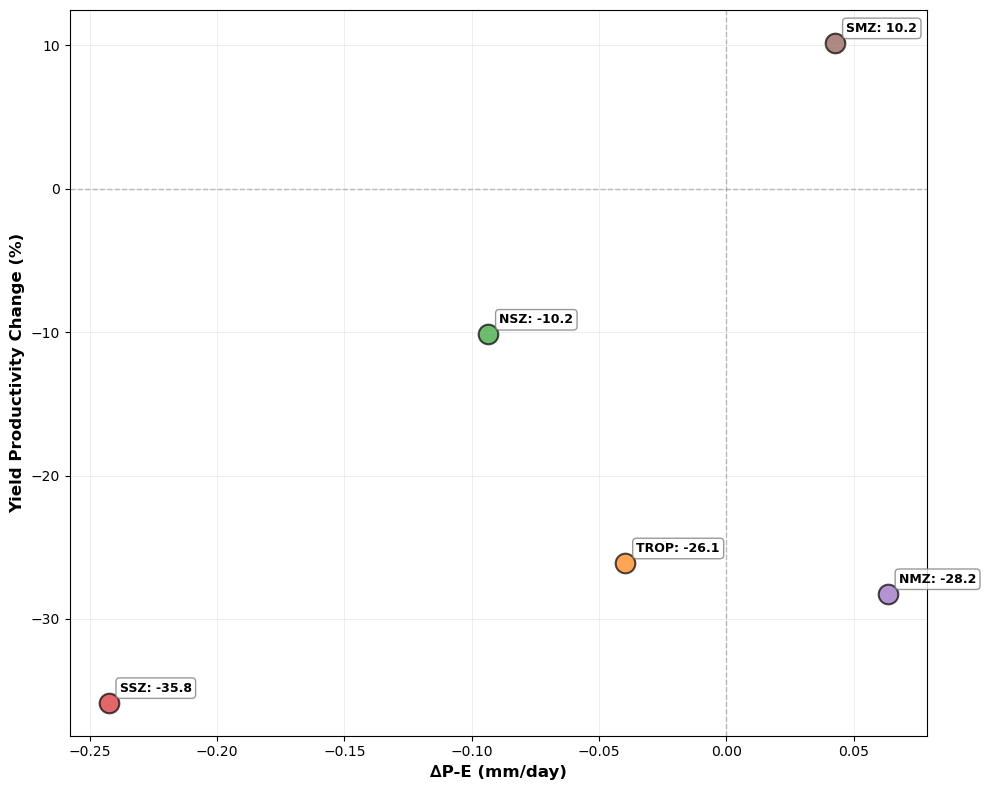


Figure saved as 'coupling_vs_yield_ensemble2.png'
Ensemble data saved to 'ensemble_summary_rice.csv'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each region
colors = {
    'SMZ': '#8c564b',
    'SSZ': '#d62728',
    'TROP': '#ff7f0e',
    'NSZ': '#2ca02c',
    'NMZ': '#9467bd'
}

# List of files to read
files = [
    ('MIROC6', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_MIROC6.csv'),
    ('NorESM2-LM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_NorESM2-LM.csv'),
    ('NorESM2-MM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_NorESM2-MM.csv'),
    ('CMCC-CM2-SR5', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_CMCC-CM2-SR5.csv'),
    ('CMCC-ESM2', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_CMCC-ESM2.csv')
]

# Read all files and store in a list
all_data = []
for model_name, filename in files:
    try:
        df = pd.read_csv(filename)
        df['model'] = model_name  # Add model identifier
        all_data.append(df)
        print(f"✓ Loaded {model_name}: {len(df)} regions")
    except FileNotFoundError:
        print(f"✗ File not found: {filename}")
        continue

# Combine all data
df_all = pd.concat(all_data, ignore_index=True)

# Calculate ensemble mean for each region
ensemble = df_all.groupby('region').agg({
    'Delta_mm_day': 'mean',
    'pct_change_M3': 'mean'
}).reset_index()

print(f"\nEnsemble statistics:")
print(ensemble)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ensemble points with region colors
for idx, row in ensemble.iterrows():
    region = row['region']
    ax.scatter(row['Delta_mm_day'], row['pct_change_M3'], 
              marker='o', s=200, alpha=0.7,
              color=colors[region],  # Color by region
              label=region,
              edgecolors='black', linewidth=1.5)

# Add region labels
    ax.annotate(f"{row['region']}: {row['pct_change_M3']:.1f}", 
           (row['Delta_mm_day'], row['pct_change_M3']),
           xytext=(8, 8), textcoords='offset points',
           fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                    edgecolor='gray', alpha=0.8))

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Labels and title
ax.set_xlabel('∆P-E (mm/day)', fontsize=12, fontweight='bold')
ax.set_ylabel('Yield Productivity Change (%)', fontsize=12, fontweight='bold')
#ax.set_title('Coupling Change vs Yield Impact (5-Model Ensemble Mean)', 
#            fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Legend
#ax.legend(loc='best', frameon=True, fontsize=10)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('coupling_vs_yield_ensemble2.png', dpi=800, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'coupling_vs_yield_ensemble2.png'")

# Optional: Save ensemble data to CSV
ensemble.to_csv('ensemble_summary_rice2.csv', index=False)
print("Ensemble data saved to 'ensemble_summary_rice.csv'")

✓ Loaded MIROC6: 5 regions
✓ Loaded NorESM2-LM: 5 regions
✓ Loaded NorESM2-MM: 5 regions
✓ Loaded CMCC-CM2-SR5: 5 regions
✓ Loaded CMCC-ESM2: 5 regions

Ensemble statistics:
  region  delta_dep  pct_change_M3
0    NMZ   0.163526     -28.248445
1    NSZ   0.020059     -10.157107
2    SMZ   0.008622      10.164441
3    SSZ   0.053776     -35.841116
4   TROP  -0.121670     -26.104519


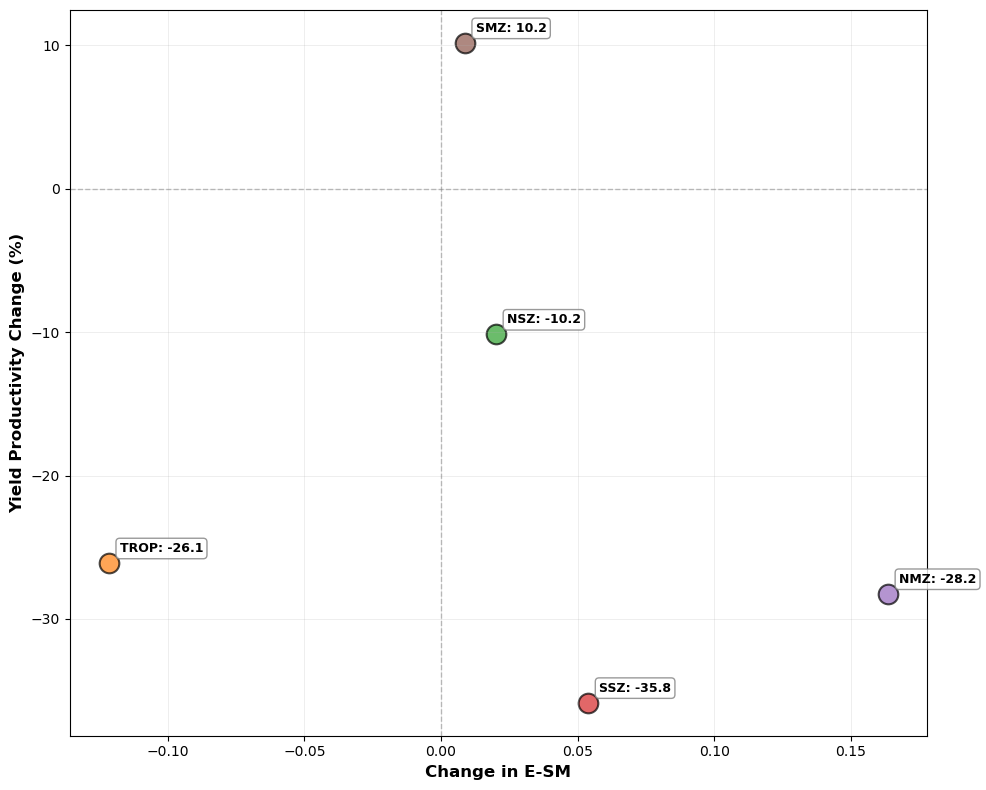


Figure saved as 'coupling_vs_yield_ensemble.png'
Ensemble data saved to 'ensemble_summary_rice.csv'


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each region
colors = {
    'SMZ': '#8c564b',
    'SSZ': '#d62728',
    'TROP': '#ff7f0e',
    'NSZ': '#2ca02c',
    'NMZ': '#9467bd'
}

# List of files to read
files = [
    ('MIROC6', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_MIROC6.csv'),
    ('NorESM2-LM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_NorESM2-LM.csv'),
    ('NorESM2-MM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_NorESM2-MM.csv'),
    ('CMCC-CM2-SR5', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_CMCC-CM2-SR5.csv'),
    ('CMCC-ESM2', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_CMCC-ESM2.csv')
]

# Read all files and store in a list
all_data = []
for model_name, filename in files:
    try:
        df = pd.read_csv(filename)
        df['model'] = model_name  # Add model identifier
        all_data.append(df)
        print(f"✓ Loaded {model_name}: {len(df)} regions")
    except FileNotFoundError:
        print(f"✗ File not found: {filename}")
        continue

# Combine all data
df_all = pd.concat(all_data, ignore_index=True)

# Calculate ensemble mean for each region
ensemble = df_all.groupby('region').agg({
    'delta_dep': 'mean',
    'pct_change_M3': 'mean'
}).reset_index()

print(f"\nEnsemble statistics:")
print(ensemble)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ensemble points with region colors
for idx, row in ensemble.iterrows():
    region = row['region']
    ax.scatter(row['delta_dep'], row['pct_change_M3'], 
              marker='o', s=200, alpha=0.7,
              color=colors[region],  # Color by region
              label=region,
              edgecolors='black', linewidth=1.5)

# Add region labels
    ax.annotate(f"{row['region']}: {row['pct_change_M3']:.1f}", 
           (row['delta_dep'], row['pct_change_M3']),
           xytext=(8, 8), textcoords='offset points',
           fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                    edgecolor='gray', alpha=0.8))

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Labels and title
ax.set_xlabel('Change in E-SM', fontsize=12, fontweight='bold')
ax.set_ylabel('Yield Productivity Change (%)', fontsize=12, fontweight='bold')
#ax.set_title('Coupling Change vs Yield Impact (5-Model Ensemble Mean)', 
#            fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Legend
#ax.legend(loc='best', frameon=True, fontsize=10)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('coupling_vs_yield_ensemble.png', dpi=800, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'coupling_vs_yield_ensemble.png'")

# Optional: Save ensemble data to CSV
ensemble.to_csv('ensemble_summary_rice.csv', index=False)
print("Ensemble data saved to 'ensemble_summary_rice.csv'")

✓ Plotted MIROC6: 5 regions
✓ Plotted NorESM2-LM: 5 regions
✓ Plotted NorESM2-MM: 5 regions
✓ Plotted CMCC-CM2-SR5: 5 regions
✓ Plotted CMCC-ESM2: 5 regions


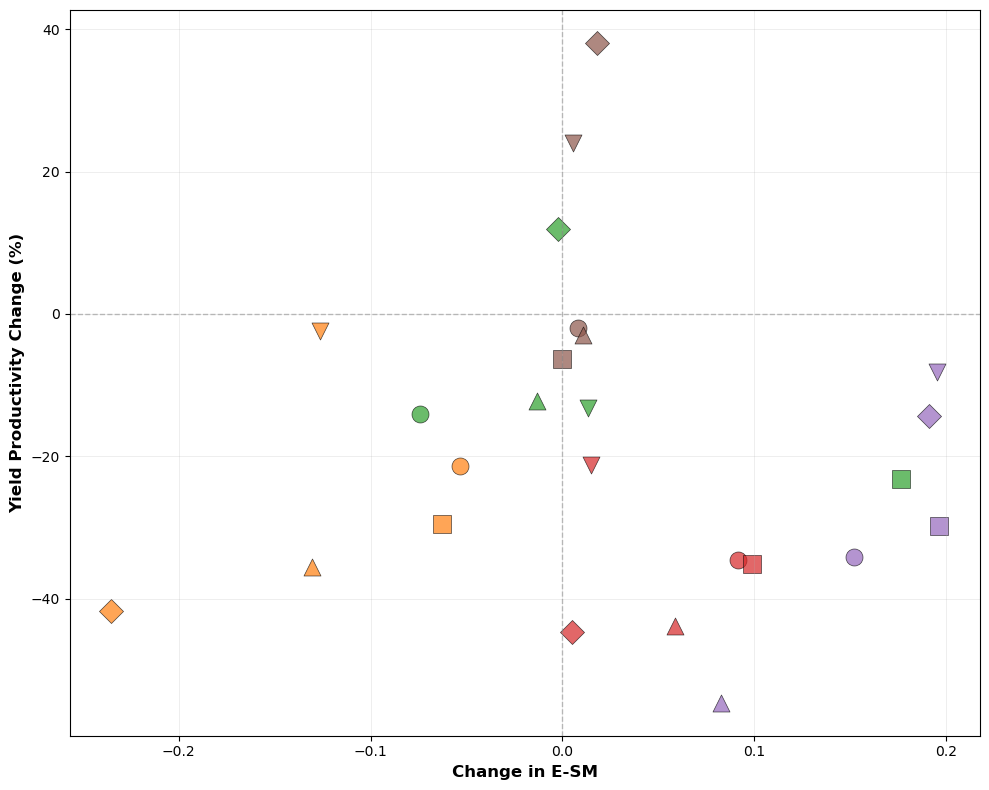


Figure saved as 'coupling_vs_yield_all_models.png'


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their markers
models = {
    'MIROC6': 'o',
    'NorESM2-LM': '^',      # Changed from 'x' to triangle for better visibility
    'NorESM2-MM': 's',      # Changed from '*' to square
    'CMCC-CM2-SR5': 'D',    # Changed from '+' to diamond
    'CMCC-ESM2': 'v',       # Changed from 'd' to inverted triangle
}

# Define colors for each region
colors = {
    'SMZ': '#8c564b',
    'SSZ': '#d62728',
    'TROP': '#ff7f0e',
    'NSZ': '#2ca02c',
    'NMZ': '#9467bd'
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# List of files to read
files = [
    ('MIROC6', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_MIROC6.csv'),
    ('NorESM2-LM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_NorESM2-LM.csv'),
    ('NorESM2-MM', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_NorESM2-MM.csv'),
    ('CMCC-CM2-SR5', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_CMCC-CM2-SR5.csv'),
    ('CMCC-ESM2', '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/historical_vs_future_summary_rice_CMCC-ESM2.csv')
]

# Track which combinations have been plotted for legend
plotted_combinations = set()

# Read and plot data for each model
for model_name, filename in files:
    try:
        # Read the CSV file for this model
        df = pd.read_csv(filename)
        
        # Plot each region for this model
        for idx, row in df.iterrows():
            region = row['region']
            
            # Create label only if this combination hasn't been plotted yet
            if (model_name, region) not in plotted_combinations:
                label = f"{model_name}-{region}"
                plotted_combinations.add((model_name, region))
            else:
                label = None
            
            ax.scatter(row['delta_dep'], row['pct_change_M3'], 
                      marker=models[model_name], s=150, alpha=0.7,
                      color=colors[region],  # Color by region
                      label=label,
                      edgecolors='black', linewidth=0.5)
        
        print(f"✓ Plotted {model_name}: {len(df)} regions")
        
    except FileNotFoundError:
        print(f"✗ File not found: {filename}")
        continue

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Labels and title
ax.set_xlabel('Change in E-SM', fontsize=12, fontweight='bold')
ax.set_ylabel('Yield Productivity Change (%)', fontsize=12, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Create custom legend with regions and models
from matplotlib.lines import Line2D

# Region legend elements
region_elements = [Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=colors[region], markersize=10,
                         markeredgecolor='black', markeredgewidth=0.5,
                         label=region) 
                  for region in colors.keys()]

# Model legend elements
#model_elements = [Line2D([0], [0], marker=models[model], color='w', 
#                        markerfacecolor='gray', markersize=10,
#                        markeredgecolor='black', markeredgewidth=0.5,
#                        label=model) 
#                 for model in models.keys()]

# Create two-column legend
#first_legend = ax.legend(handles=region_elements, loc='upper left', 
#                        title='Region', frameon=True, fontsize=9)
#ax.add_artist(first_legend)
#ax.legend(handles=model_elements, loc='upper right', 
#         title='Model', frameon=True, fontsize=9)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('coupling_vs_yield_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'coupling_vs_yield_all_models.png'")

Loaded: NorESM2-LM
Loaded: MIROC6
Loaded: NorESM2-MM
Loaded: CMCC-CM2-SR5
Loaded: CMCC-ESM2

Regions found: ['R01_SM', 'R02_SS', 'R03_Tropics', 'R04_NS', 'R05_NM']
Update the region_colors dictionary with these region names if needed



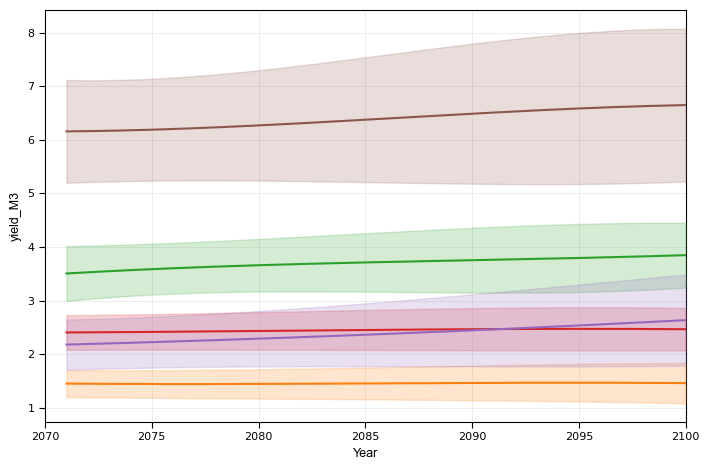


Processed 5 models
Number of regions: 5
Regions: R01_SM, R02_SS, R03_Tropics, R04_NS, R05_NM


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# List your model files
model_files = [
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_MIROC6.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-MM.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-CM2-SR5.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-ESM2.csv'
]

# Read all models
all_data = []
for file in model_files:
    try:
        df = pd.read_csv(file)
        model_name = file.split('_')[-1].replace('.csv', '')
        df['model'] = model_name
        all_data.append(df)
        print(f"Loaded: {model_name}")
    except FileNotFoundError:
        print(f"Warning: Could not find {file}")

if not all_data:
    raise ValueError("No data files were successfully loaded!")

# Combine all models
combined_df = pd.concat(all_data, ignore_index=True)

# Get unique regions
regions = sorted(combined_df['region'].unique())

# Define manual colors for each region
# Adjust these colors based on your preference
region_colors = {
    'R01_SM': '#8c564b',      # Blue
    'R02_SS': '#d62728',      # Orange
    'R03_Tropics': '#ff7f0e', # Green
    'R04_NS': '#2ca02c',      # Red
    'R05_NM': '#9467bd',      # Purple
}

# If you have different region names, print them first to see what they are
print(f"\nRegions found: {regions}")
print("Update the region_colors dictionary with these region names if needed\n")

# Create the plot
fig, ax = plt.subplots(figsize=(7.2, 4.8))

# Plot each region
for i, region in enumerate(regions):
    # Get color for this region (fallback to tab10 if not defined)
    color = region_colors.get(region, plt.cm.tab10(i / len(regions)))
    
    # Filter data for this region
    region_data = combined_df[combined_df['region'] == region]
    
    # Group by year and calculate ensemble mean and std across models
    region_yearly = region_data.groupby('year')['yield_M3'].agg(['mean', 'std']).reset_index()
    
    years_region = region_yearly['year'].values
    yield_mean = region_yearly['mean'].values
    yield_std = region_yearly['std'].values
    
    # Replace NaN std with 0
    yield_std = np.nan_to_num(yield_std, nan=0.0)
    
    # Create smooth spline fit for mean
    years_dense = np.linspace(years_region.min(), years_region.max(), 200)
    spline_mean = UnivariateSpline(years_region, yield_mean, s=len(years_region)*0.05, k=3)
    yield_smooth = spline_mean(years_dense)
    
    # Create smooth spline fit for std
    spline_std = UnivariateSpline(years_region, yield_std, s=len(years_region)*0.05, k=3)
    std_smooth = spline_std(years_dense)
    
    # Plot mean line
    ax.plot(years_dense, yield_smooth, '-', linewidth=1.5, 
            color=color, label=region, zorder=10)
    
    # Plot shaded ±1 std
    ax.fill_between(years_dense, 
                     yield_smooth - std_smooth, 
                     yield_smooth + std_smooth,
                     alpha=0.2, color=color, zorder=5)

# Set x-axis limits
ax.set_xlim(2070, 2100)

# Formatting
ax.set_xlabel('Year', fontsize=9, fontname='Arial')
ax.set_ylabel('yield_M3', fontsize=9, fontname='Arial')
#ax.set_title('Regional Ensemble Projections of Yield (Model 3)', 
#             fontsize=10, fontname='Arial', fontweight='bold')

# Legend
#ax.legend(loc='best', fontsize=7, frameon=False, ncol=5)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=8, direction='out', 
               length=4, width=0.8)

# Grid
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, color='gray')

# Spine width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()

# Save figures
plt.savefig('regional_yield_projections.png', dpi=600, bbox_inches='tight')

plt.show()

print(f"\nProcessed {len(model_files)} models")
print(f"Number of regions: {len(regions)}")
print(f"Regions: {', '.join(regions)}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


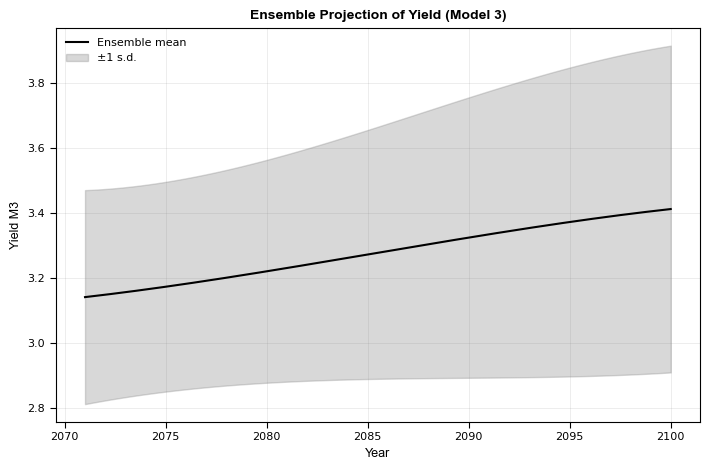

Processed 5 models
Years range: 2071 - 2100
Ensemble mean yield range: 3.14 - 3.41

Figures saved in TIFF, EPS, PDF, and PNG formats


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# List your model files
model_files = [
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-LM.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_MIROC6.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_NorESM2-MM.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-CM2-SR5.csv',
    '/Users/dianindrawati/Documents/Python/CMIP6_and_ERA5/future_yield_projections_rice_CMCC-ESM2.csv'
]

# Read all models and calculate mean yield_M3 across regions for each year
model_data = []
for file in model_files:
    df = pd.read_csv(file)
    # Group by year and calculate mean yield across all regions
    yearly_mean = df.groupby('year')['yield_M3'].mean().reset_index()
    model_data.append(yearly_mean)

# Get years (should be same across all models)
years = model_data[0]['year'].values

# Extract yield_M3 from each model
yield_arrays = []
for df in model_data:
    yield_arrays.append(df['yield_M3'].values)

# Stack into array: (n_models, n_years)
yield_stack = np.array(yield_arrays)

# Calculate ensemble mean and standard deviation across models
ensemble_mean = np.mean(yield_stack, axis=0)
ensemble_std = np.std(yield_stack, axis=0)

# Create smooth spline fits
# Create dense x-axis for smooth curves
years_dense = np.linspace(years.min(), years.max(), 300)

# Fit spline to ensemble mean (s parameter controls smoothness)
spline_mean = UnivariateSpline(years, ensemble_mean, s=len(years)*0.5, k=3)
ensemble_mean_smooth = spline_mean(years_dense)

# Fit spline to standard deviation
spline_std = UnivariateSpline(years, ensemble_std, s=len(years)*0.5, k=3)
ensemble_std_smooth = spline_std(years_dense)

# Create the plot with Nature specifications
fig, ax = plt.subplots(figsize=(7.2, 4.8))  # ~183mm width for double column

# Plot smooth mean line
ax.plot(years_dense, ensemble_mean_smooth, 'k-', linewidth=1.5, label='Ensemble mean')

# Plot shaded standard deviation
ax.fill_between(years_dense, 
                 ensemble_mean_smooth - ensemble_std_smooth, 
                 ensemble_mean_smooth + ensemble_std_smooth,
                 alpha=0.3, color='gray', label='±1 s.d.')

# Formatting for Nature style
ax.set_xlabel('Year', fontsize=9, fontname='Arial')
ax.set_ylabel('Yield M3', fontsize=9, fontname='Arial')
ax.set_title('Ensemble Projection of Yield (Model 3)', fontsize=10, fontname='Arial', fontweight='bold')

# Legend with Nature style
ax.legend(loc='best', fontsize=8, frameon=False)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=8, direction='out', length=4, width=0.8)

# Clean grid (optional)
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, color='gray')

# Set spine width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout()

# Save in multiple formats for Nature submission
plt.savefig('ensemble_yield_projection.tiff', dpi=600, bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig('ensemble_yield_projection.eps', dpi=600, bbox_inches='tight', format='eps')
plt.savefig('ensemble_yield_projection.pdf', dpi=600, bbox_inches='tight')
plt.savefig('ensemble_yield_projection.png', dpi=600, bbox_inches='tight')

plt.show()

print(f"Processed {len(model_files)} models")
print(f"Years range: {years.min()} - {years.max()}")
print(f"Ensemble mean yield range: {ensemble_mean_smooth.min():.2f} - {ensemble_mean_smooth.max():.2f}")
print("\nFigures saved in TIFF, EPS, PDF, and PNG formats")